In [1]:
import cdsapi
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import math

In [2]:
def download_wind(year, month, day, locations, filepath):
    c = cdsapi.Client()
    c.retrieve(
        "reanalysis-era5-single-levels",
        {
            "product_type": ["reanalysis"],
            "variable": [
                "10m_u_component_of_wind",
                "10m_v_component_of_wind",
            ],
            "year": year,
            "month": month,
            "day": day,
            "time": [
                "00:00",
                "01:00",
                "02:00",
                "03:00",
                "04:00",
                "05:00",
                "06:00",
                "07:00",
                "08:00",
                "09:00",
                "10:00",
                "11:00",
                "12:00",
                "13:00",
                "14:00",
                "15:00",
                "16:00",
                "17:00",
                "18:00",
                "19:00",
                "20:00",
                "21:00",
                "22:00",
                "23:00",
            ],
            "data_format": "netcdf",
            "download_format": "unarchived",
            "area": locations,
        },
        filepath,
    )

In [5]:
all_data = pd.read_csv("data_details.csv")
all_data[all_data["plume"] == 2]

,index,path,cloudy,note,sub_path,site,latitude,longitude,Time,Attribute,Size,solar_zenith_angle,viewing_zenith_angle,height,width,plume
19,19,ori_data/A1/2021-02-17,0,0,A1,A1,31.748240,6.003124,17/02/2021,Algeria,"-196,217",48.431120,10.098127,196,217,2
338,338,ori_data/A1/2023-05-06,0,0,A1,A1,31.748240,6.003124,06/05/2023,Algeria,"-196,217",20.542372,8.778128,196,217,2
763,763,ori_data/A3/2021-01-13,0,0,A3,A3,31.777500,5.996545,13/01/2021,Algeria,"-183,227",56.768380,10.203178,183,227,2
775,775,ori_data/A3/2021-02-12,0,0,A3,A3,31.777500,5.996545,12/02/2021,Algeria,"-183,227",50.030018,10.216820,183,227,2
777,777,ori_data/A3/2021-02-17,0,0,A3,A3,31.777500,5.996545,17/02/2021,Algeria,"-183,227",48.451200,10.222898,183,227,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13570,13570,ori_data/U16/2023-08-20,0,0,U16,U16,31.363118,-101.775200,20/08/2023,HE,"-196,217",25.728031,5.712129,196,217,2
13651,13651,ori_data/U17/2021-03-28,0,0,U17,U17,31.186819,-101.657800,28/03/2021,HE,"-196,217",33.215904,4.569382,196,217,2
13652,13652,ori_data/U17/2021-04-02,0,0,U17,U17,31.186819,-101.657800,02/04/2021,HE,"-196,217",31.373104,4.614713,196,217,2
14113,14113,ori_data/U2/2022-07-26,0,0,U2,U2,31.733500,-102.042100,26/07/2022,HE,"-184,227",21.756000,8.519069,184,227,2


In [ ]:
# Download dataset
plume_data = all_data[all_data["plume"] == 2]
for index, data in plume_data.iterrows():
    year, month, day = data["path"].split("/")[-1].split("-")
    x1, y1, x2, y2 = (
        math.ceil(data["latitude"]),
        math.floor(data["longitude"]),
        math.floor(data["latitude"]),
        math.ceil(data["longitude"]),
    )
    locations = [x1, y1, x2, y2]
    subname = str(data["index"])
    filepath = "./dataset/wind/" + subname + ".nc"
    download_wind(year, month, day, locations, filepath)
    print(locations, filepath)
    break

In [6]:
all_data[all_data["index"] == 10034]

,index,path,cloudy,note,sub_path,site,latitude,longitude,Time,Attribute,Size,solar_zenith_angle,viewing_zenith_angle,height,width,plume
10034,10034,ori_data/T9/2022-04-29,0,0,T9,T9,39.36045,53.76506,29/04/2022,Turkmenistan,"-166,227",28.568396,8.090673,166,227,2


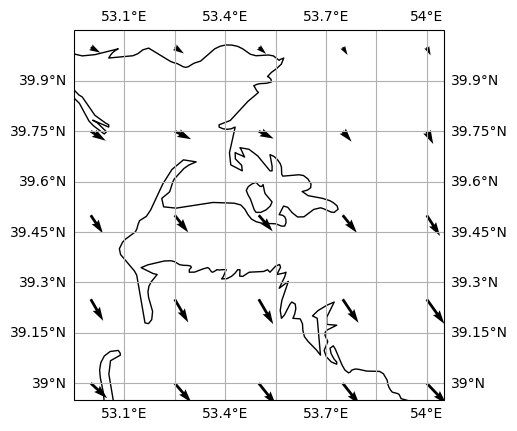

In [ ]:
data = xr.open_dataset("./dataset/wind/10034.nc")
time_index = 18

# Extraction
lon = data["longitude"]
lat = data["latitude"]
v10 = data["v10"]
u10 = data["u10"]
time = data["valid_time"]

# Wind speed and direction
wind_speed = np.sqrt(u10**2 + v10**2)
wind_direction = np.arctan2(v10, u10) * (180 / np.pi)

# Projection
ax = plt.axes(projection=ccrs.PlateCarree())

# Wind Direction
ax.quiver(
    lon, lat, u10[time_index, :, :], v10[time_index, :, :], transform=ccrs.PlateCarree()
)

# Coastline
ax.coastlines()
ax.gridlines(draw_labels=True)

plt.show()

In [11]:
data["v10"][18, :, :]

<xarray.DataArray 'v10' (latitude: 5, longitude: 5)> Size: 100B
array([[-1.108826, -1.284607, -1.364685, -1.603943, -1.670349],
       [-1.938904, -1.635193, -1.507263, -2.138123, -2.621521],
       [-3.714294, -3.525818, -3.303162, -3.60199 , -4.251404],
       [-4.422302, -4.761169, -5.110779, -4.835388, -5.054138],
       [-3.060974, -3.949646, -4.425232, -4.382263, -4.220154]], dtype=float32)
Coordinates:
    number      int64 8B ...
    valid_time  datetime64[ns] 8B 2022-04-29T18:00:00
  * latitude    (latitude) float64 40B 40.0 39.75 39.5 39.25 39.0
  * longitude   (longitude) float64 40B 53.0 53.25 53.5 53.75 54.0
    expver      <U4 16B ...
Attributes: (12/32)
    GRIB_paramId:                             166
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      25
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                10 metre V wind component
    units:                                    m s**-1
    standard_name:                            unknown
    GRIB_surface:                             0.0